### 3. Percentile Method
* The percentile method identifies outliers as data points that lie below a lower percentile or above an upper percentile of the dataset.

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df = pd.read_csv('weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [6]:
print(df['Height'].skew())
print(df['Weight'].skew())

0.04936908937689042
0.03295450444592442


<Axes: ylabel='Height'>

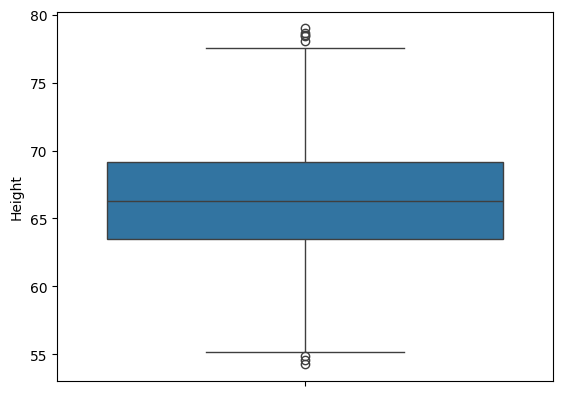

In [7]:
sns.boxplot(df['Height'])

<Axes: ylabel='Weight'>

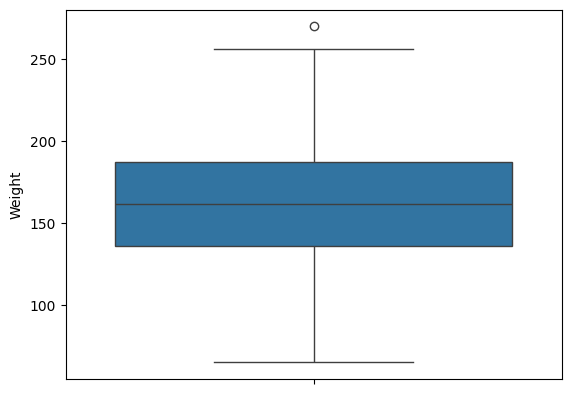

In [8]:
sns.boxplot(df['Weight'])

In [9]:
df.shape


(10000, 3)

In [11]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


* we have outliers in the height column 
* defining the range of the dataset
* upper_limit = 99 percentile 
* lower_limit = 1 percentile 
* we can define any lower and upper limit but the sum of both must be 100 percentle 

In [25]:
upper_limit = df['Height'].quantile(0.99)
lower_limit = df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [19]:
# finding the data data that is greater than the upper limit 
df[df['Height'] > upper_limit].count()

Gender    100
Height    100
Weight    100
dtype: int64

In [20]:
df[df['Height'] < lower_limit].count()

Gender    100
Height    100
Weight    100
dtype: int64

#### Trimming

In [27]:
new_df = df[(df['Height'] <= upper_limit) & (df['Height'] >= lower_limit)]

In [28]:
new_df.shape

(9800, 3)

In [29]:
new_df.describe()

,Height,Weight
count,9800.000000,9800.000000
mean,66.364366,161.399489
std,3.645075,30.933549
min,58.134496,77.523774
25%,63.577162,136.322717
50%,66.318070,161.212928
75%,69.119896,186.753317
max,74.785714,249.946283


<Axes: ylabel='Height'>

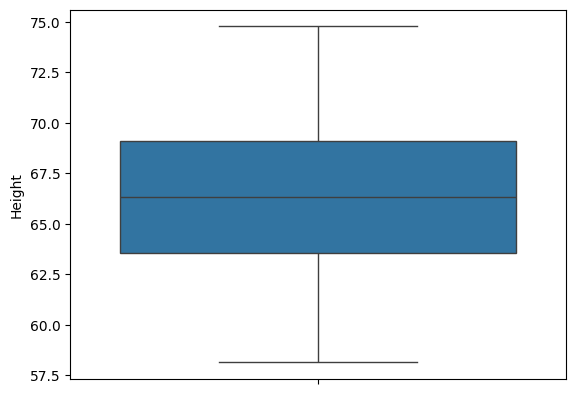

In [30]:
sns.boxplot(new_df['Height'])

### Capping 
* it is also called **winsorization**

In [32]:
df['Height'] = np.where(
    df['Height'] >= upper_limit,
    upper_limit,
    np.where(
        df['Height'] <= lower_limit,
        lower_limit,
        df['Height']
    )
) 

In [34]:
df.shape

(10000, 3)

<Axes: ylabel='Height'>

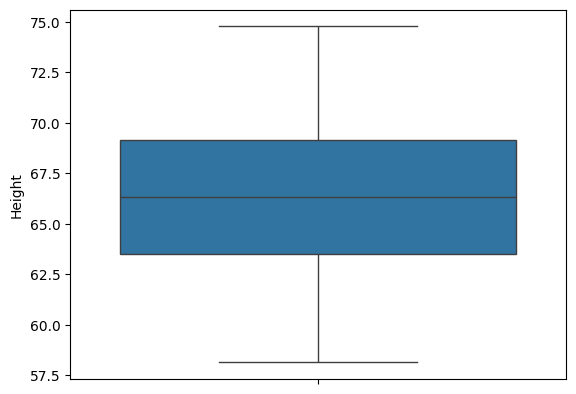

In [36]:
sns.boxplot(df['Height'])